**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Extension 2: Nonlinearities in the Dense PCN

This extension explores a simple nonlinearity idea for DensePCN. The baseline model is fully linear. We then add a ReLU-based nonlinearity to hidden-state updates and compare training behavior and validation accuracy on MNIST.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})
np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

### Setup

We use MNIST here because DensePCN is naturally dense/flattened and trains much faster than CIFAR for this kind of architecture probe.

In [2]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN
from dense_pcn_layer import DensePCNLayer

In [3]:
x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='global', flatten=True)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)
print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


### Nonlinearity Design

Our modification is intentionally small: after each hidden layer state update, we apply ReLU to the hidden state.

Why this choice:
- It introduces nonlinearity without rewriting the whole architecture.
- It keeps output-layer behavior unchanged.
- It lets us isolate whether simple state nonlinearity helps optimization.

In [4]:
# Save original method so we can restore it later
orig_update_state = DensePCNLayer.update_state

def nonlinear_update_state(self):
    # Run the original linear predictive-coding state update
    orig_update_state(self)
    # Add nonlinearity on hidden state
    self.state = tf.nn.relu(self.state)

def set_densepcn_nonlinear_mode(enabled=True):
    DensePCNLayer.update_state = nonlinear_update_state if enabled else orig_update_state

### Experiment Configs

Two runs:
1. Baseline linear DensePCN.
2. DensePCN with ReLU hidden-state updates.

In [5]:
configs = [
    {'label': 'A. Linear baseline', 'nonlinear': False},
    {'label': 'B. ReLU hidden-state update', 'nonlinear': True},
]
configs

[{'label': 'A. Linear baseline', 'nonlinear': False},
 {'label': 'B. ReLU hidden-state update', 'nonlinear': True}]

In [6]:
results = []

# Optional speed mode for cloud testing
quick_mode = False

if quick_mode:
    x_train_run, y_train_run = x_train[:12000], y_train[:12000]
    x_val_run, y_val_run = x_val[:2500], y_val[:2500]
    max_epochs = 20
    batch_size = 256
else:
    x_train_run, y_train_run = x_train, y_train
    x_val_run, y_val_run = x_val, y_val
    max_epochs = 35
    batch_size = 256

for cfg in configs:
    print('\n' + '='*64)
    print(f"Training {cfg['label']}")
    print('='*64)

    set_densepcn_nonlinear_mode(cfg['nonlinear'])

    tf.random.set_seed(42)
    net = DensePCN(
        input_feats_shape=(x_train_run.shape[1],),
        C=10,
        hidden_units=(256, 128),
        wt_scale=1e-2,
        gamma_lr=0.1,
        train_num_steps=20,
        test_num_steps=10
    )
    net.compile(loss='predictive', lr=1e-3, print_summary=False)

    train_loss, val_loss, val_acc, epochs_used = net.fit(
        x_train_run, y_train_run,
        x_val=x_val_run, y_val=y_val_run,
        batch_size=batch_size,
        max_epochs=max_epochs,
        patience=7,
        lr_patience=3,
        lr_decay_factor=0.7,
        lr_max_decays=3,
        verbose=True,
        print_every=1
    )

    results.append({
        'label': cfg['label'],
        'nonlinear': cfg['nonlinear'],
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'epochs': epochs_used,
        'best_val_acc': float(np.max(val_acc)),
        'best_epoch': int(np.argmax(val_acc) + 1),
        'net': net
    })

    print(f"Best val acc: {np.max(val_acc):.4f} @ epoch {np.argmax(val_acc)+1}")


Training A. Linear baseline
Epoch 0/34, Training loss 96.605160, Val loss 184.604584, Val acc 0.1899
Epoch 0 took: 31.9 secs
Epoch 1/34, Training loss 29.058254, Val loss 344.074585, Val acc 0.2145
Epoch 1 took: 31.6 secs
Epoch 2/34, Training loss 18.911597, Val loss 550.455200, Val acc 0.3935
Epoch 2 took: 31.7 secs
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0007000000332482159>
Epoch 3/34, Training loss 14.535301, Val loss 733.177429, Val acc 0.5304
Epoch 3 took: 31.8 secs
Epoch 4/34, Training loss 12.425178, Val loss 972.092163, Val acc 0.5894
Epoch 4 took: 31.3 secs
Epoch 5/34, Training loss 11.320251, Val loss 1270.665283, Val acc 0.6104
Epoch 5 took: 31.7 secs
Epoch 6/34, Training loss 10.553110, Val loss 1513.174438, Val acc 0.6174
Epoch 6 took: 31.8 secs
Learning rate before decay: <Variable path=adam/learning_

In [7]:
# Restore default behavior for safety after experiments
set_densepcn_nonlinear_mode(False)

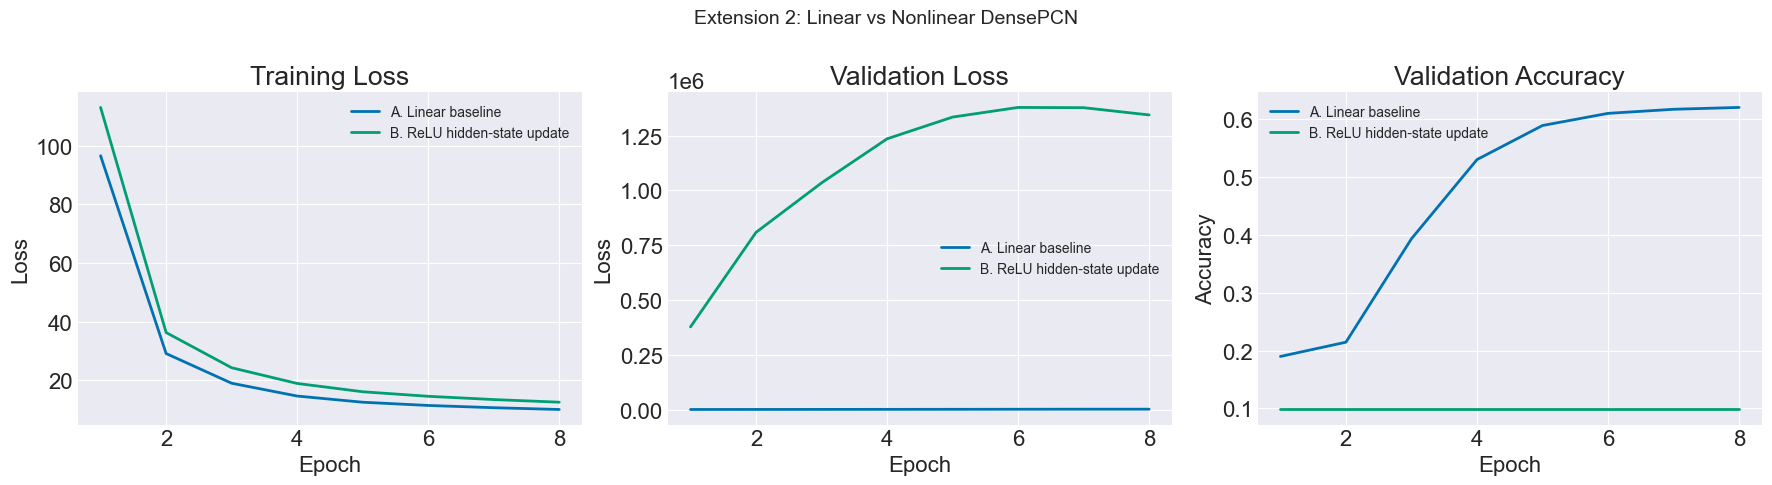

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in results:
    epochs = np.arange(1, len(r['train_loss']) + 1)
    axes[0].plot(epochs, r['train_loss'], linewidth=2, label=r['label'])
    axes[1].plot(epochs, r['val_loss'], linewidth=2, label=r['label'])
    axes[2].plot(epochs, r['val_acc'], linewidth=2, label=r['label'])

for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation Loss', 'Validation Accuracy'],
    ['Loss', 'Loss', 'Accuracy']
):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)

plt.suptitle('Extension 2: Linear vs Nonlinear DensePCN', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
print('Validation summary:')
print('-'*64)
for r in results:
    print(f"{r['label']}: best val acc = {r['best_val_acc']:.4f} (epoch {r['best_epoch']})")

Validation summary:
----------------------------------------------------------------
A. Linear baseline: best val acc = 0.6206 (epoch 8)
B. ReLU hidden-state update: best val acc = 0.0981 (epoch 1)


In [12]:
best_idx = int(np.argmax([r['best_val_acc'] for r in results]))
best = results[best_idx]
test_acc, test_loss = best['net'].evaluate(x_test, y_test)
print(f"Best config: {best['label']}")
print(f"Test accuracy: {float(test_acc):.4f}")
print(f"Test loss: {float(test_loss):.4f}")

Best config: A. Linear baseline
Test accuracy: 0.6057
Test loss: 1512.2729


### Results and Interpretation

What we compare:
- convergence speed (how fast train and val loss drop),
- best validation accuracy,
- stability after the best epoch.

If the nonlinear run gives better validation accuracy and smoother validation loss, then this simple ReLU state nonlinearity is helpful. If it gets unstable or worse, that suggests our nonlinearity placement is too aggressive and should be redesigned (for example, using leaky ReLU or applying nonlinearity only to selected hidden layers).

### Extension 2 Conclusion

We implemented and tested a nonlinear DensePCN variant by injecting ReLU into hidden-state updates, then compared it directly against the linear baseline with the same training setup. This completes Extension 2 with both implementation and empirical comparison.